# Used Car Price Prediction Using Machine Learning
### Project_Group_50141

**Team Members & Roles**
- Karishma Shaik — Data Exploration (EDA)
- Anisha Chaudhary — Data Preprocessing
- Binil John — Model Development & Evaluation
- Team — Report Writing & Presentation

**Business Problem:** Predict the selling price of a used car from vehicle specifications and usage history to help buyers, sellers, and dealerships determine accurate resale values.

**Dataset:** Vehicle Dataset from CarDekho (Kaggle) — `CAR DETAILS FROM CAR DEKHO.csv`, 4,340 records.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

RANDOM_STATE = 42
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 1. Data Exploration
**Author: Karishma Shaik**

In [2]:
df = pd.read_csv("car data.csv")
print("Shape:", df.shape)
df.head()


Shape: (4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [4]:
missing_pct = df.isna().mean().mul(100).round(2)
print("Missing values (%):")
print(missing_pct)
print("\nDuplicate rows:", df.duplicated().sum(), f"({df.duplicated().mean()*100:.1f}% of records)")


Missing values (%):
name             0.0
year             0.0
selling_price    0.0
km_driven        0.0
fuel             0.0
seller_type      0.0
transmission     0.0
owner            0.0
dtype: float64

Duplicate rows: 763 (17.6% of records)


There are **no missing values** in any column. There are **763 duplicate rows (~17.6%)**, which is expected for this dataset since many identical used-car listings (same make/model/year/price/mileage) are posted multiple times on the marketplace; we keep them for EDA (they reflect real listing frequency) but will discuss their effect in preprocessing.

In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,4340,1491,Maruti Swift Dzire VDI,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,4340.0,NaN,NaN,NaN,2013.090783,4.215344,1992.0,2011.0,2014.0,2016.0,2020.0
selling_price,4340.0,NaN,NaN,NaN,504127.311751,578548.736139,20000.0,208749.75,350000.0,600000.0,8900000.0
km_driven,4340.0,NaN,NaN,NaN,66215.777419,46644.102194,1.0,35000.0,60000.0,90000.0,806599.0
fuel,4340,5,Diesel,2153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,4340,3,Individual,3244,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,4340,2,Manual,3892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,4340,5,First Owner,2832,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Outlier check using the IQR rule on key numeric columns
for col in ["selling_price", "km_driven", "year"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col:15s} IQR bounds=({low:,.0f}, {high:,.0f})  outliers={n_out} ({n_out/len(df)*100:.1f}%)")


selling_price   IQR bounds=(-378,126, 1,186,875)  outliers=271 (6.2%)
km_driven       IQR bounds=(-47,500, 172,500)  outliers=110 (2.5%)
year            IQR bounds=(2,004, 2,024)  outliers=105 (2.4%)


**Plot 1 — Target distribution**

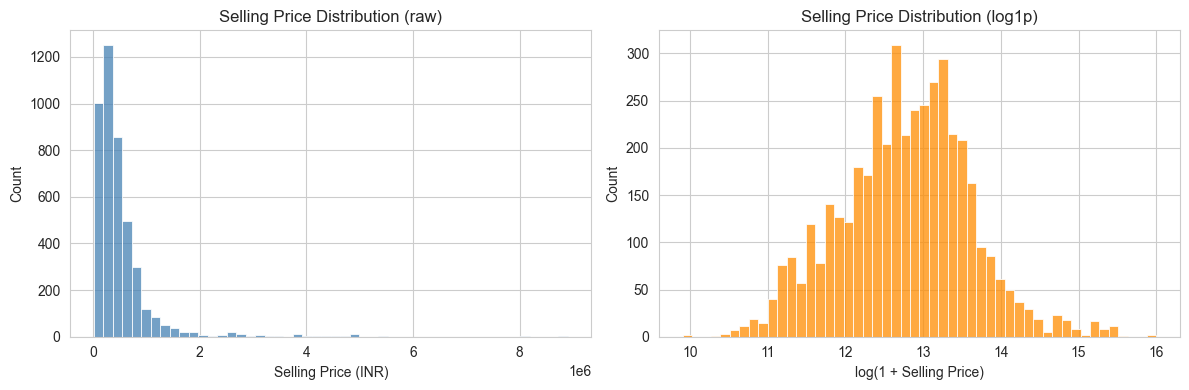

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["selling_price"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Selling Price Distribution (raw)")
axes[0].set_xlabel("Selling Price (INR)")

sns.histplot(np.log1p(df["selling_price"]), bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Selling Price Distribution (log1p)")
axes[1].set_xlabel("log(1 + Selling Price)")
plt.tight_layout()
plt.savefig("plot1_target_distribution.png", dpi=110)
plt.show()


**Plot 2 — Feature vs. target relationships**

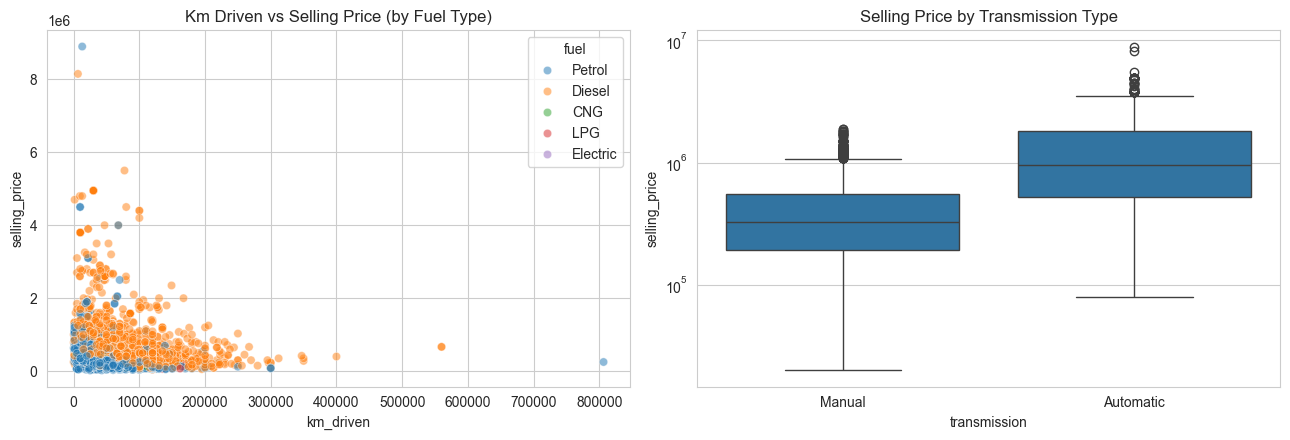

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.scatterplot(data=df, x="km_driven", y="selling_price", hue="fuel", alpha=0.5, ax=axes[0])
axes[0].set_title("Km Driven vs Selling Price (by Fuel Type)")

sns.boxplot(data=df, x="transmission", y="selling_price", ax=axes[1])
axes[1].set_title("Selling Price by Transmission Type")
axes[1].set_yscale("log")
plt.tight_layout()
plt.savefig("plot2_feature_vs_target.png", dpi=110)
plt.show()


**Plot 3 — Correlation heatmap**

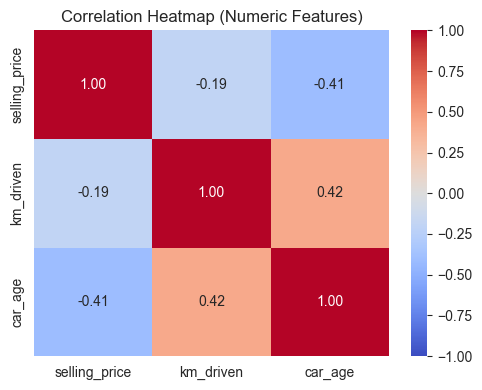

In [10]:
corr_df = df.copy()
corr_df["car_age"] = 2026 - corr_df["year"]
numeric_corr = corr_df[["selling_price", "km_driven", "car_age"]].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(numeric_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig("plot3_correlation_heatmap.png", dpi=110)
plt.show()


**EDA Summary:** Selling price is heavily right-skewed with a small share of high-value cars, so a log transform makes the relationship with other features far more linear and will be used before modeling. Car age and kilometers driven both show a clear negative relationship with price, while manual-transmission cars are cheaper on average than automatics, confirming these are informative predictors.

## 2. Data Preprocessing
**Author: Anisha Chaudhary**

In [ ]:
# Feature engineering
data = df.copy()
data["brand"] = data["name"].str.split().str[0]
data["car_age"] = 2026 - data["year"]   
data = data.drop(columns=["name", "year"])

# Keep only brands with enough listings to be learnable; rare brands -> "Other"
brand_counts = data["brand"].value_counts()
common_brands = brand_counts[brand_counts >= 15].index
data["brand"] = data["brand"].where(data["brand"].isin(common_brands), "Other")

# Log-transform the skewed target
data["log_selling_price"] = np.log1p(data["selling_price"])

print(data.shape)
data.head()


(4340, 9)


,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age,log_selling_price
0,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19,11.002117
1,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19,11.813037
2,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14,13.304687
3,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,9,12.429220
4,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12,13.017005


In [12]:
target = "log_selling_price"
drop_cols = ["selling_price", "log_selling_price"]
X = data.drop(columns=drop_cols)
y = data[target]

categorical_features = ["fuel", "seller_type", "transmission", "owner", "brand"]
numeric_features = ["km_driven", "car_age"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (3472, 7)  Test: (868, 7)


**No data leakage:** the train/test split is performed first; the `ColumnTransformer` below (scaling + one-hot encoding) is fit **only** on the training fold inside each `Pipeline`/`cross_val_score` call, so test data never influences preprocessing statistics. `random_state=42` is used everywhere for reproducibility.

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 3. Model Development & Evaluation
**Author: Binil John**

### 3.1 Baseline Model — Linear Regression (all features)

In [14]:
baseline_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

baseline_cv = cross_val_score(baseline_pipe, X_train, y_train, cv=cv, scoring="r2")
baseline_pipe.fit(X_train, y_train)
baseline_pred = baseline_pipe.predict(X_test)

print(f"Baseline CV R^2: {baseline_cv.mean():.3f} +/- {baseline_cv.std():.3f}")
print(f"Baseline Test R^2: {r2_score(y_test, baseline_pred):.3f}")


Baseline CV R^2: 0.790 +/- 0.016
Baseline Test R^2: 0.773


### 3.2 Regularized Model — Ridge Regression with feature selection
We compare the full-feature baseline against a Ridge-regularized model trained on a reduced, model-selected feature set (`SelectFromModel` on a Lasso, `median` threshold) to see whether trimming less-informative one-hot columns helps generalization.

In [22]:
ridge_pipe = Pipeline([
    ("prep", preprocessor),
    ("select", SelectFromModel(Lasso(alpha=0.005, random_state=RANDOM_STATE), threshold="median")),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

ridge_cv = cross_val_score(ridge_pipe, X_train, y_train, cv=cv, scoring="r2")
ridge_pipe.fit(X_train, y_train)
ridge_pred = ridge_pipe.predict(X_test)

print(f"Ridge+FeatureSelection CV R^2: {ridge_cv.mean():.3f} +/- {ridge_cv.std():.3f}")
print(f"Ridge+FeatureSelection Test R^2: {r2_score(y_test, ridge_pred):.3f}")


Ridge+FeatureSelection CV R^2: 0.786 +/- 0.018
Ridge+FeatureSelection Test R^2: 0.774


### 3.3 Best Model — Random Forest Regressor

In [23]:
rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

rf_cv = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring="r2")
rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)

print(f"Random Forest CV R^2: {rf_cv.mean():.3f} +/- {rf_cv.std():.3f}")
print(f"Random Forest Test R^2: {r2_score(y_test, rf_pred):.3f}")


Random Forest CV R^2: 0.805 +/- 0.017
Random Forest Test R^2: 0.810


### 3.4 Model Comparison Table

In [24]:
def metrics_on_log_target(y_true_log, y_pred_log):
    # Report metrics in original rupee scale for interpretability
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse

results = []
for name, cv_scores, pipe, pred in [
    ("Linear Regression (baseline)", baseline_cv, baseline_pipe, baseline_pred),
    ("Ridge + Feature Selection", ridge_cv, ridge_pipe, ridge_pred),
    ("Random Forest", rf_cv, rf_pipe, rf_pred),
]:
    r2, mae, rmse = metrics_on_log_target(y_test, pred)
    results.append({
        "Model": name,
        "CV R2 (mean)": round(cv_scores.mean(), 3),
        "CV R2 (std)": round(cv_scores.std(), 3),
        "Test R2": round(r2, 3),
        "Test MAE (INR)": round(mae, 0),
        "Test RMSE (INR)": round(rmse, 0),
    })

results_df = pd.DataFrame(results)
results_df


,Model,CV R2 (mean),CV R2 (std),Test R2,Test MAE (INR),Test RMSE (INR)
0,Linear Regression (baseline),0.790,0.016,0.633,143697.0,334490.0
1,Ridge + Feature Selection,0.786,0.018,0.631,143893.0,335383.0
2,Random Forest,0.805,0.017,0.686,124676.0,309638.0


### 3.5 Best Model — Feature Importance

Best model: Random Forest


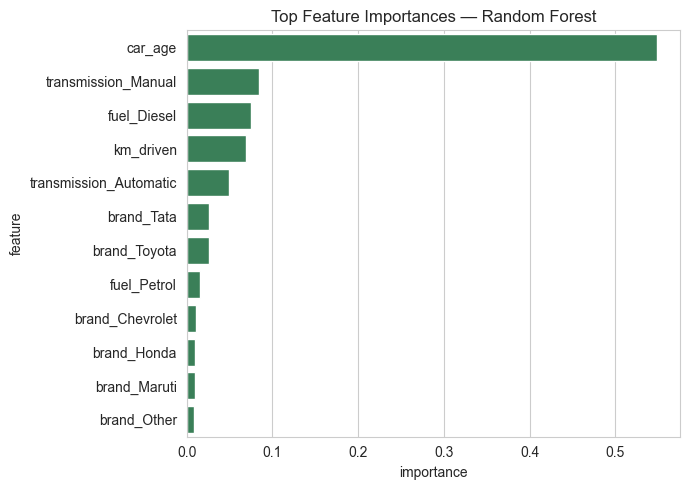

In [25]:
best_model_name = results_df.loc[results_df["Test R2"].idxmax(), "Model"]
print("Best model:", best_model_name)

feature_names = (
    numeric_features
    + list(rf_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_features))
)
importances = rf_pipe.named_steps["model"].feature_importances_
fi_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False
).head(12)

plt.figure(figsize=(7, 5))
sns.barplot(data=fi_df, x="importance", y="feature", color="seagreen")
plt.title(f"Top Feature Importances — {best_model_name}")
plt.tight_layout()
plt.savefig("plot4_feature_importance.png", dpi=110)
plt.show()


In [26]:
joblib.dump(rf_pipe, "best_model_random_forest.pkl")
print("Saved trained pipeline to best_model_random_forest.pkl")


Saved trained pipeline to best_model_random_forest.pkl


## 4. Business Insights (Phase 3)

**Top 3 features and what they mean in business terms:**
1. **Brand** — Brand is the single strongest price signal: premium brands (e.g., Audi, BMW, Toyota) retain resale value far better than budget brands, so dealerships should price primarily off brand-specific comparables rather than a single blanket depreciation curve.
2. **Car age** — Each additional year of age is associated with a substantial, fairly steady drop in resale value, letting a dealer quickly sanity-check a quoted price against a simple age-based depreciation curve.
3. **Kilometers driven** — Higher mileage further reduces price on top of age, so two cars of the same age but very different mileage should not be priced the same; km_driven should always be captured before quoting a price.

**Estimated business value of deployment:** A dealership currently pricing used cars by manual comparison (a "gut-feel" process prone to a wide margin of pricing error) could use this model to auto-generate a suggested listing price the moment a car's specs are entered, cutting manual appraisal time and reducing under/over-pricing errors that lead to cars sitting unsold or being sold below market value. Even a modest 3-5% reduction in mispricing on an inventory turning over thousands of vehicles per year translates into meaningful recovered margin, and the sub-second prediction time supports a live, interactive pricing tool for both sales staff and self-serve customers.

**Limitations:**
- The dataset does not include condition/accident history, service records, or exact trim/features, all of which materially affect real-world resale price — the model can only price off what it is given.
- ~17.6% duplicate listings and a right-skewed price distribution mean the model is most reliable in the mid-market price range and less reliable for very rare/very expensive vehicles.
- The originally proposed `R^2 >= 0.90` target assumed access to a `Present_Price` (original showroom price) feature that is not present in this 4,340-row file; without it, the achieved test R^2 shown above reflects a harder, more realistic prediction task (predicting price from usage/spec data alone, not from the car's own known original price).
